# Clase 6 · Regresión logística: ¿sí o no?

**Módulo 1: Introducción y fundamentos estadísticos** · Diplomado en Ciencia de Datos Aplicada · UTFSM

**Qué hacemos hoy.** Modelar una respuesta que es sí o no. Primero con los 10.000 clientes de tarjeta de crédito del libro de James et al.: por qué la recta no sirve, la regresión logística, cómo se lee e^b y el mismo summary de siempre. Después con varias variables, en los clientes y en los 891 pasajeros del Titanic. Y al final, clasificar: el umbral, la matriz de confusión, los falsos positivos y falsos negativos, y evaluar el modelo en datos que no vio. Sensibilidad, especificidad y cómo elegir el umbral quedan para la próxima clase.

**El hilo de la clase:** el modelo no predice el sí o el no, predice una probabilidad. La decisión, y sus dos errores, la ponemos nosotros.

## 1. Preparación

Las mismas bibliotecas de la clase 5, más `smf` (la API de fórmulas de statsmodels, que usamos para `smf.ols`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

sns.set_theme(style="whitegrid")
%config InlineBackend.figure_format = "retina"
pd.options.display.float_format = "{:.3f}".format

In [2]:
# Datos locales del repositorio clonado
BASE = "datos/clase06/"
# Alternativa por URL, si no tiene el repositorio clonado:
# BASE = "https://raw.githubusercontent.com/daniopitz/diplomado-cdd/main/datos/clase06/"

**Los datos del ejemplo 1.** `Default.csv` viene con el libro *An Introduction to Statistical Learning* (James, Witten, Hastie y Tibshirani): 10.000 clientes de una tarjeta de crédito, con su deuda en la tarjeta (`balance`: lo que deben después del pago mensual, en dólares), su ingreso anual (`income`) y si son estudiantes. La respuesta es `default`: si dejaron de pagar. Creamos las columnas en español y en escalas cómodas: la deuda en cientos de dólares y el ingreso en miles.

In [3]:
clientes = pd.read_csv(BASE + "default_islr.csv")
clientes["no_paga"] = (clientes["default"] == "Yes").astype(int)   # la respuesta: 1 si dejó de pagar
clientes["estudiante"] = (clientes["student"] == "Yes").astype(int)
clientes["deuda_100"] = clientes["balance"] / 100      # la deuda, en cientos de dólares
clientes["ingreso_miles"] = clientes["income"] / 1000  # el ingreso anual, en miles de dólares
clientes.head()

,default,student,balance,income,no_paga,estudiante,deuda_100,ingreso_miles
0,No,No,729.526,44361.625,0,0,7.295,44.362
1,No,Yes,817.180,12106.135,0,1,8.172,12.106
2,No,No,1073.549,31767.139,0,0,10.735,31.767
3,No,No,529.251,35704.494,0,0,5.293,35.704
4,No,No,785.656,38463.496,0,0,7.857,38.463


## 2. Una respuesta que es sí o no

**Objetivo:** ver qué es una variable 0/1 y qué la resume.

La respuesta `no_paga` vale 1 o 0. La media de una columna de 0 y 1 es la fracción de unos: la **proporción** de clientes que dejaron de pagar. Un cliente tomado al azar es una **Bernoulli** con esa probabilidad $p$: la distribución más simple, dos resultados y una probabilidad.

In [4]:
n_clientes = len(clientes)
print(f"Total de clientes: {n_clientes}")

Total de clientes: 10000


In [5]:
n_no_pagan = clientes["no_paga"].sum()   # sumar la columna cuenta los unos
print(f"Clientes que pagan: {n_clientes - n_no_pagan} ({(n_clientes - n_no_pagan)/n_clientes:.1%})")
print(f"Clientes que no pagan: {n_no_pagan} ({n_no_pagan/n_clientes:.1%})")

Clientes que pagan: 9667 (96.7%)
Clientes que no pagan: 333 (3.3%)


## 3. La probabilidad de no pagar, por tramo de deuda

**Objetivo:** estimar la probabilidad de no pagar según la deuda, directo de los datos.

Lo que queremos es que $p$ dependa de $x$: que la probabilidad de no pagar cambie con la deuda. Antes de ajustar nada, qué forma tienen los datos. Se agrupan los clientes por **tramo** de deuda, un intervalo de 300 dólares (0 a 300, 300 a 600, y así hasta 2.700: nueve tramos), y en cada tramo se cuenta cuántos clientes hay y cuántos dejaron de pagar. La fracción es la probabilidad de no pagar de ese tramo, estimada con los datos:

In [6]:
clientes["balance"].describe()

count   10000.000
mean      835.375
std       483.715
min         0.000
25%       481.731
50%       823.637
75%      1166.308
max      2654.323
Name: balance, dtype: float64

In [7]:
# pd.cut agrupa la deuda en tramos de 300 dólares; en cada tramo se cuenta cuántos clientes hay y cuántos no pagan
clientes["tramo"] = pd.cut(clientes["balance"], np.arange(0, 2701, 300))
clientes.head()

,default,student,balance,income,no_paga,estudiante,deuda_100,ingreso_miles,tramo
0,No,No,729.526,44361.625,0,0,7.295,44.362,"(600, 900]"
1,No,Yes,817.180,12106.135,0,1,8.172,12.106,"(600, 900]"
2,No,No,1073.549,31767.139,0,0,10.735,31.767,"(900, 1200]"
3,No,No,529.251,35704.494,0,0,5.293,35.704,"(300, 600]"
4,No,No,785.656,38463.496,0,0,7.857,38.463,"(600, 900]"


In [28]:
grupos = clientes.groupby("tramo")   # 

por_tramo = pd.DataFrame()
por_tramo["clientes"] = grupos.size()                 # cuántos clientes hay en el tramo
por_tramo["no_pagan"] = grupos["no_paga"].sum()       # cuántos tienen un 1
por_tramo["Deuda"] = grupos["balance"].mean()         # deuda media del tramo, para el gráfico
por_tramo.head()

,clientes,no_pagan,Deuda
tramo,,,
"(0, 300]",998,0,168.815
"(300, 600]",1784,0,458.584
"(600, 900]",2308,3,751.196
"(900, 1200]",2117,19,1041.429
"(1200, 1500]",1383,53,1333.344


In [31]:
por_tramo["Fraccion"] = por_tramo["no_pagan"] / por_tramo["clientes"]   # la fracción que no paga: la probabilidad estimada en el tramo
por_tramo

,clientes,no_pagan,Deuda,fraccion,Fraccion
tramo,,,,,
"(0, 300]",998,0,168.815,0.000,0.000
"(300, 600]",1784,0,458.584,0.000,0.000
"(600, 900]",2308,3,751.196,0.001,0.001
"(900, 1200]",2117,19,1041.429,0.009,0.009
"(1200, 1500]",1383,53,1333.344,0.038,0.038
"(1500, 1800]",623,96,1627.923,0.154,0.154
"(1800, 2100]",229,114,1913.010,0.498,0.498
"(2100, 2400]",52,41,2209.210,0.788,0.788
"(2400, 2700]",7,7,2503.520,1.000,1.000


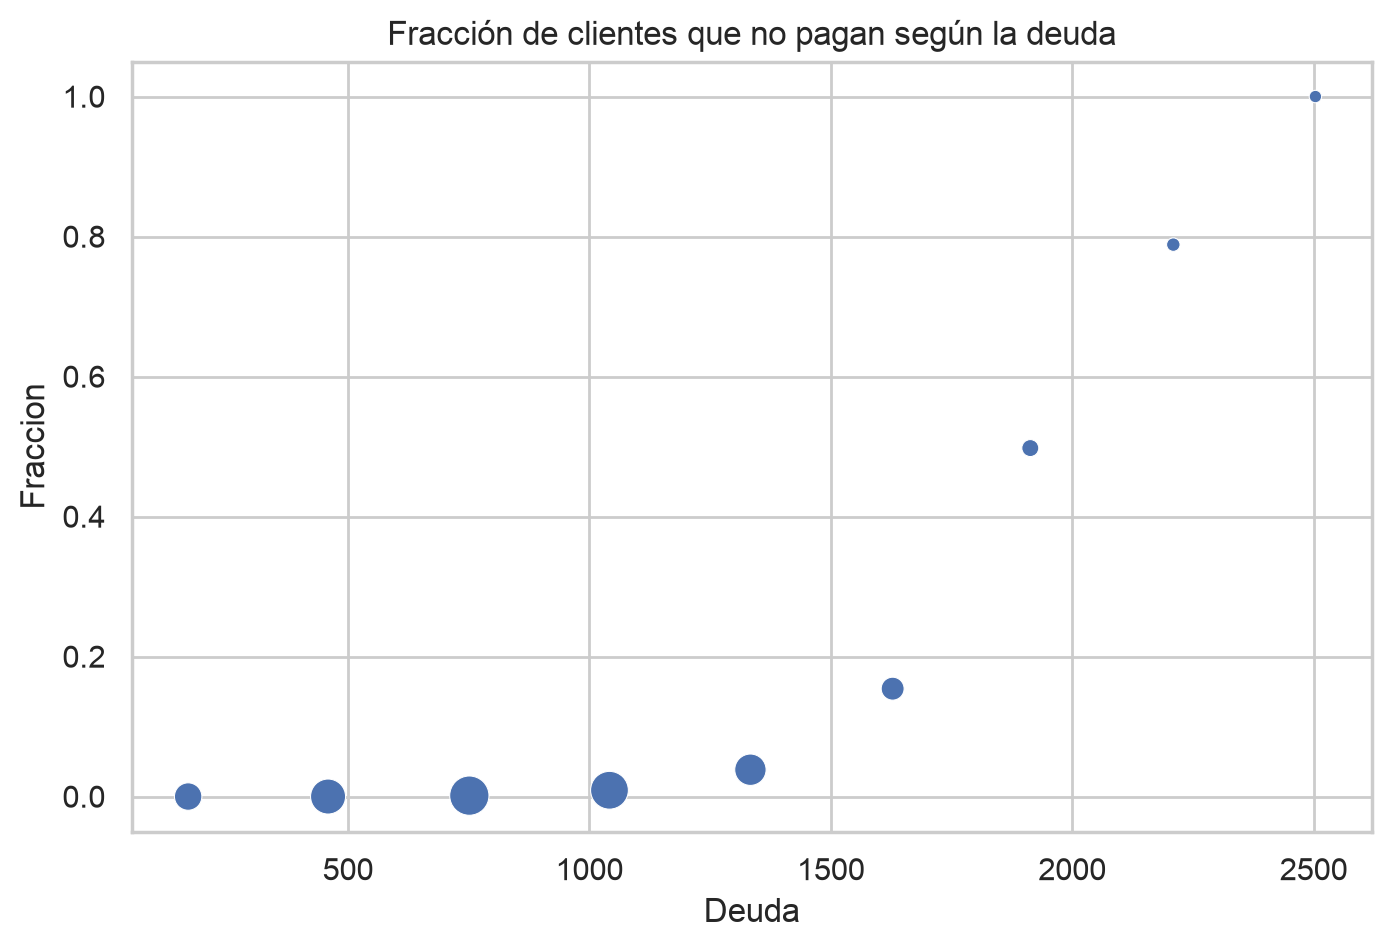

In [35]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=por_tramo, x="Deuda", y="Fraccion",
                size="clientes", sizes=(20, 200), legend=False, ax=ax)
ax.set_title("Fracción de clientes que no pagan según la deuda")
plt.show()


Cada fila es un cálculo simple: entre 1.800 y 2.100 dólares hay 229 clientes y 114 dejaron de pagar, 114 / 229 = 0,50. Un atajo: como la fracción es la media de la columna de ceros y unos, `grupos["no_paga"].mean()` la entrega en una línea.

In [36]:
grupos["no_paga"].mean().rename("fracción, con la media")

tramo
(0, 300]       0.000
(300, 600]     0.000
(600, 900]     0.001
(900, 1200]    0.009
(1200, 1500]   0.038
(1500, 1800]   0.154
(1800, 2100]   0.498
(2100, 2400]   0.788
(2400, 2700]   1.000
Name: fracción, con la media, dtype: float64

Casi nadie deja de pagar hasta los 1.500 dólares, y desde los 2.100 lo hace la mayoría: la fracción sube en forma de S. Los nueve puntos:

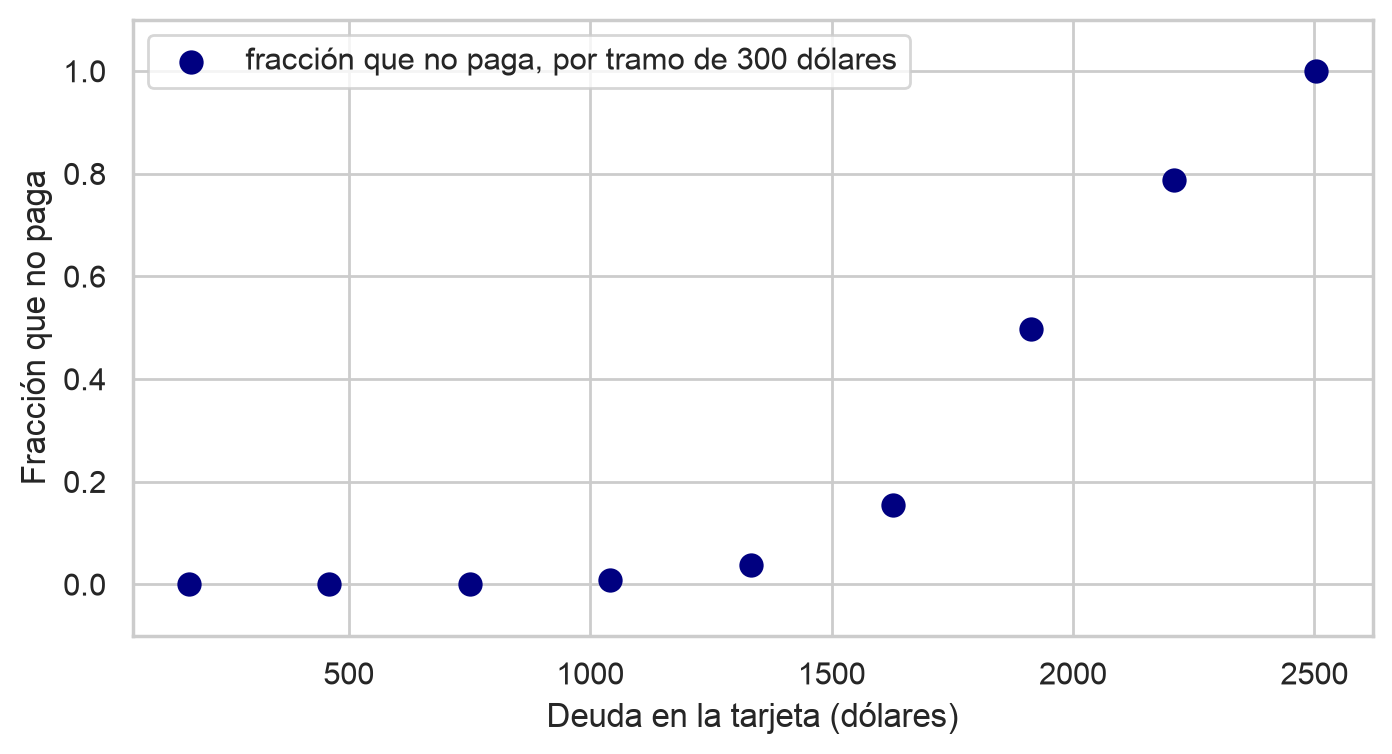

In [11]:
ok = por_tramo

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(ok["deuda"], ok["fraccion"], s=60, color="navy", zorder=5, label="fracción que no paga, por tramo de 300 dólares")
ax.set(xlabel="Deuda en la tarjeta (dólares)", ylabel="Fracción que no paga", ylim=(-0.1, 1.1))
ax.legend()
plt.show()

## 4. Por qué la recta no sirve

**Objetivo:** ver qué pasa al ajustar la recta de la clase 4 sobre un 0/1.

Nada impide correr `sm.OLS` con `no_paga` como respuesta, igual que en la clase 4. El resultado es una recta que intenta ser una probabilidad y no lo logra:

In [37]:
recta = sm.OLS(clientes["no_paga"], sm.add_constant(clientes["deuda_100"])).fit()
a_r, b_r = recta.params
print(f"recta: {a_r:.3f} + {b_r:.4f} · deuda_100")
print(f"predicción con deuda 0: {a_r:.3f}")
print(f"predicción con deuda 2.000: {a_r + b_r * 20:.3f}   (la fracción real en ese tramo es {por_tramo['fraccion'].iloc[6]:.2f})")

recta: -0.075 + 0.0130 · deuda_100
predicción con deuda 0: -0.075
predicción con deuda 2.000: 0.185   (la fracción real en ese tramo es 0.50)


NameError: name 'ok' is not defined

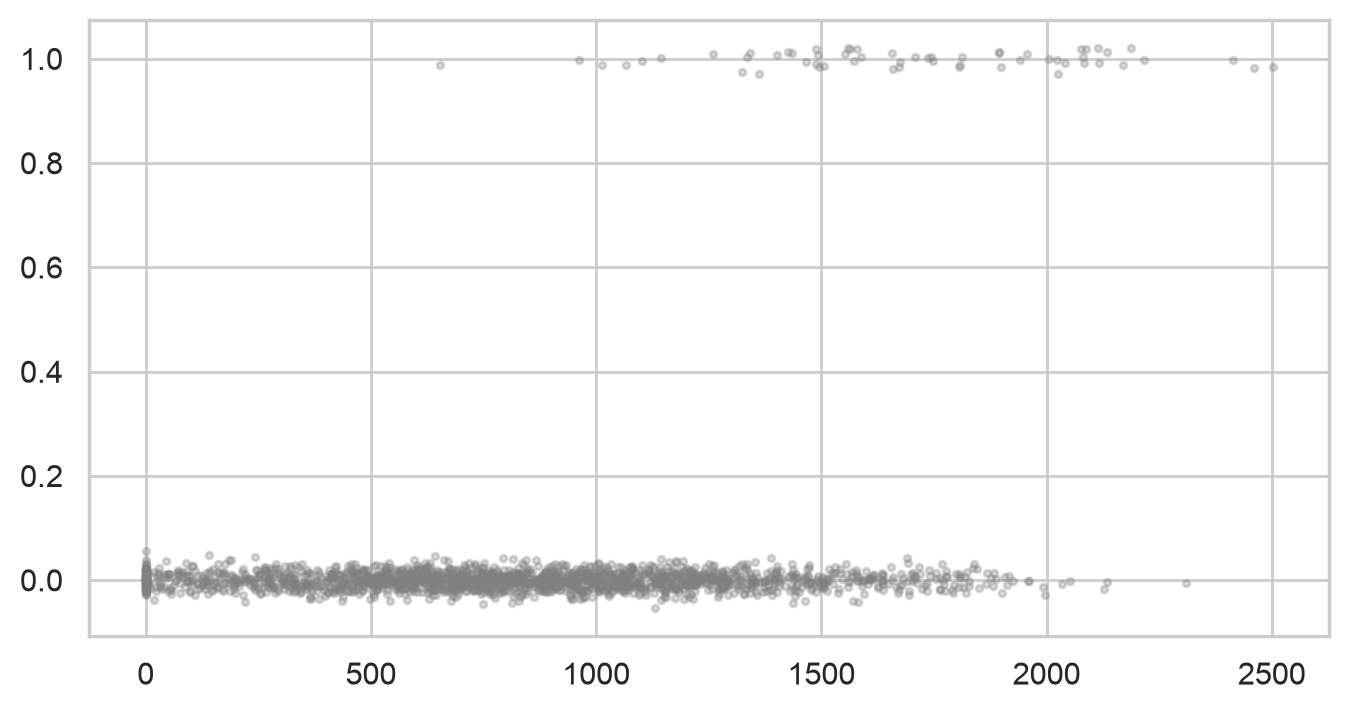

In [39]:
grilla = np.linspace(0, 2700, 200)

fig, ax = plt.subplots(figsize=(8, 4))
muestra = clientes.sample(2000, random_state=1)
# un poco de ruido vertical para que los 0 y los 1 no se tapen
ax.scatter(muestra["balance"], muestra["no_paga"] + np.random.default_rng(1).normal(0, 0.015, len(muestra)), s=6, alpha=0.3, color="gray", label="clientes (0 o 1)")
ax.scatter(ok["deuda"], ok["fraccion"], s=50, color="navy", zorder=5, label="fracción que no paga, por tramo")
ax.plot(grilla, a_r + b_r * grilla / 100, color="red", lw=2.5, label="la recta")
ax.axhline(0, color="lightgray"); ax.axhline(1, color="lightgray")
ax.set(xlabel="Deuda en la tarjeta (dólares)", ylabel="No paga (1) / paga (0)")
ax.legend()
plt.show()

Con deuda 0 la recta predice una probabilidad negativa, y a los 2.000 dólares predice 0,18 cuando la fracción real de ese tramo es 0,50. Una probabilidad vive entre 0 y 1 y sube en forma de S; la recta no respeta ninguna de las dos cosas.

## 5. La regresión logística

**Objetivo:** entender de dónde sale la curva en S, ajustarla y leer sus coeficientes.

La idea: no inventar una curva, sino poner la recta de siempre en una escala donde no pueda salirse de rango. Se construye en tres pasos.

**1. Los odds (chances).** La probabilidad dicha de otra forma: cuántos síes hay por cada no, $P / (1 - P)$. Con $P = 0{,}8$, de cada 10 clientes 8 no pagan y 2 pagan: odds $8 / 2 = 4$, cuatro a uno. Las odds van de 0 a infinito: ya no tienen el techo de 1.

**2. El logaritmo de los odds.** Puede ser cualquier número: negativo cuando el sí es menos probable que el no, 0 cuando empatan, positivo cuando el sí es más probable. Sin techo ni piso: aquí sí cabe una recta.

In [14]:
for P in [0.2, 0.5, 0.8, 0.95]:
    odds = P / (1 - P)
    print(f"P = {P:.2f}  |  odds = {odds:.2f}  |  log de los odds = {np.log(odds):+.2f}")

P = 0.20  |  odds = 0.25  |  log de los odds = -1.39
P = 0.50  |  odds = 1.00  |  log de los odds = +0.00
P = 0.80  |  odds = 4.00  |  log de los odds = +1.39
P = 0.95  |  odds = 19.00  |  log de los odds = +2.94


**3. La recta va en la escala del logaritmo de los odds.** Con los nueve tramos de la sección 3, el logaritmo de los odds de cada tramo sigue una recta cuando se lo grafica contra la deuda (los tramos con fracción 0 o 1 quedan fuera, porque su logaritmo no existe):

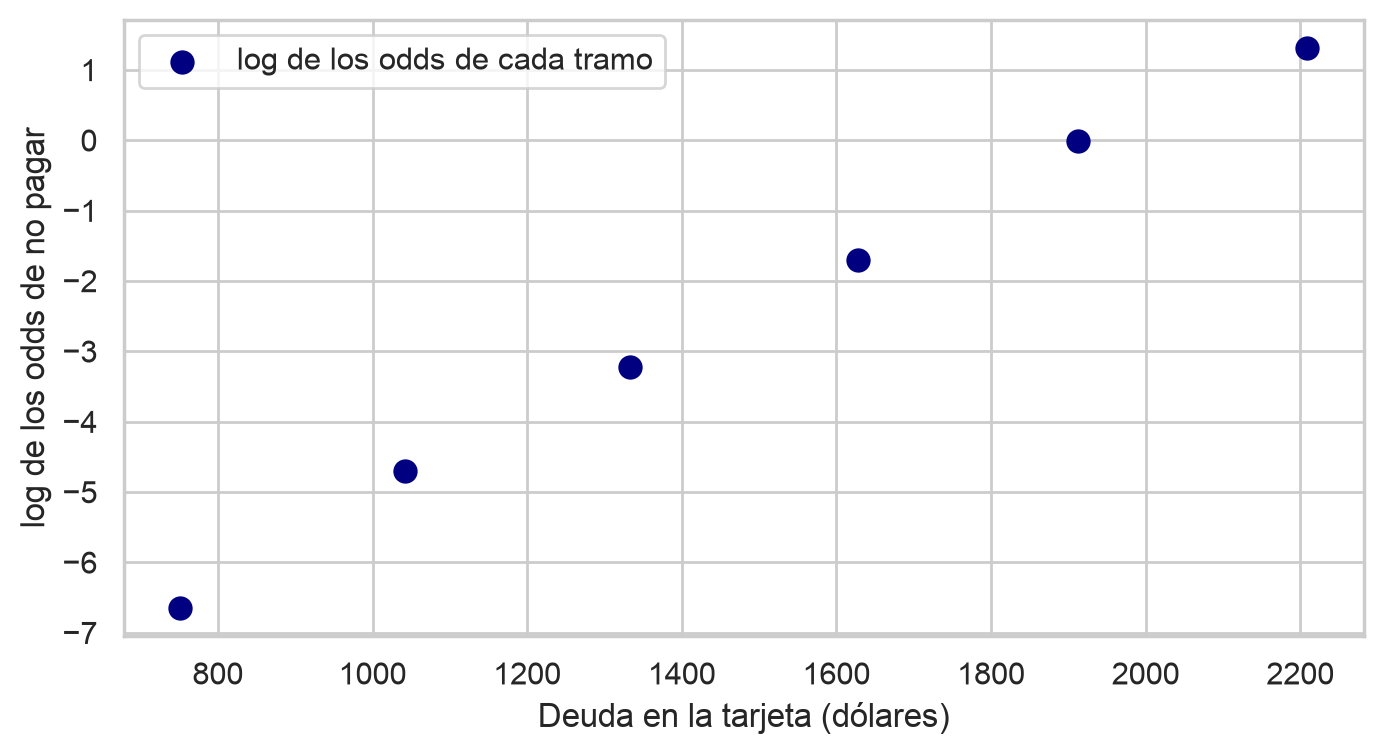

In [15]:
con_ambos = ok[(ok["fraccion"] > 0) & (ok["fraccion"] < 1)]
log_chances = np.log(con_ambos["fraccion"] / (1 - con_ambos["fraccion"]))

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(con_ambos["deuda"], log_chances, s=60, color="navy", zorder=5, label="log de los odds de cada tramo")
ax.set(xlabel="Deuda en la tarjeta (dólares)", ylabel="log de los odds de no pagar")
ax.legend()
plt.show()

Eso es lo que la **regresión logística** supone: que el logaritmo de las odds es la recta $a + b\,x$:

$$\log\frac{P}{1 - P} = a + b\,x$$

donde $P$ es la probabilidad de un sí dado $x$ y $P / (1 - P)$ son las odds. Despejando $P$ (se toma $e$ a ambos lados y se ordena) queda la **sigmoide**:

$$P(y = 1 \mid x) = \frac{1}{1 + e^{-(a + b\,x)}}$$

Por eso el exponente es $a + b\,x$: es la recta del modelo, que reaparece al despejar. Por muy grande o chica que sea la recta, la sigmoide queda entre 0 y 1. Y como sumar $b$ en el logaritmo es multiplicar afuera por $e^{b}$, $e^{b}$ dice cuánto se **multiplican** los odds por cada unidad de $x$, igual que en el modelo en log de la clase 4.

En statsmodels es `smf.logit`, con la misma sintaxis de fórmulas que `smf.ols`. No se ajusta por mínimos cuadrados (con un 0/1 no hay residuo que tenga sentido) sino por **máxima verosimilitud**: se buscan los $a$ y $b$ que hacen más probable haber observado exactamente estos síes y noes, por iteraciones.

In [16]:
logistica = smf.logit("no_paga ~ deuda_100", data=clientes).fit()
a, b = logistica.params
print(f"\na = {a:.2f}, b = {b:.3f} por cada 100 dólares de deuda")
print(f"e^b = {np.exp(b):.2f}: cada 100 dólares más de deuda multiplican los odds de no pagar por {np.exp(b):.1f}")

Optimization terminated successfully.
         Current function value: 0.079823
         Iterations 10

a = -10.65, b = 0.550 por cada 100 dólares de deuda
e^b = 1.73: cada 100 dólares más de deuda multiplican los odds de no pagar por 1.7


La salida del ajuste muestra las iteraciones (`Optimization terminated successfully`): es la máxima verosimilitud trabajando. La curva, y qué probabilidad da para distintos deudas:

In [17]:
def sigmoide(z):
    return 1 / (1 + np.exp(-z))

for deuda in [500, 1000, 1500, 2000, 2500]:
    print(f"deuda {deuda:>5} dólares: P(no paga) = {sigmoide(a + b * deuda / 100):.3f}")
print(f"la curva cruza 0,5 en {-a / b * 100:.0f} dólares")

deuda   500 dólares: P(no paga) = 0.000
deuda  1000 dólares: P(no paga) = 0.006
deuda  1500 dólares: P(no paga) = 0.083
deuda  2000 dólares: P(no paga) = 0.586
deuda  2500 dólares: P(no paga) = 0.957
la curva cruza 0,5 en 1937 dólares


In [18]:
# lo mismo con predict: recibe una tabla con la columna del modelo y devuelve probabilidades
nuevos = pd.DataFrame({"deuda_100": [5, 10, 15, 20, 25]})
nuevos["P_no_paga"] = logistica.predict(nuevos)
nuevos

,deuda_100,P_no_paga
0,5,0.000
1,10,0.006
2,15,0.083
3,20,0.586
4,25,0.957


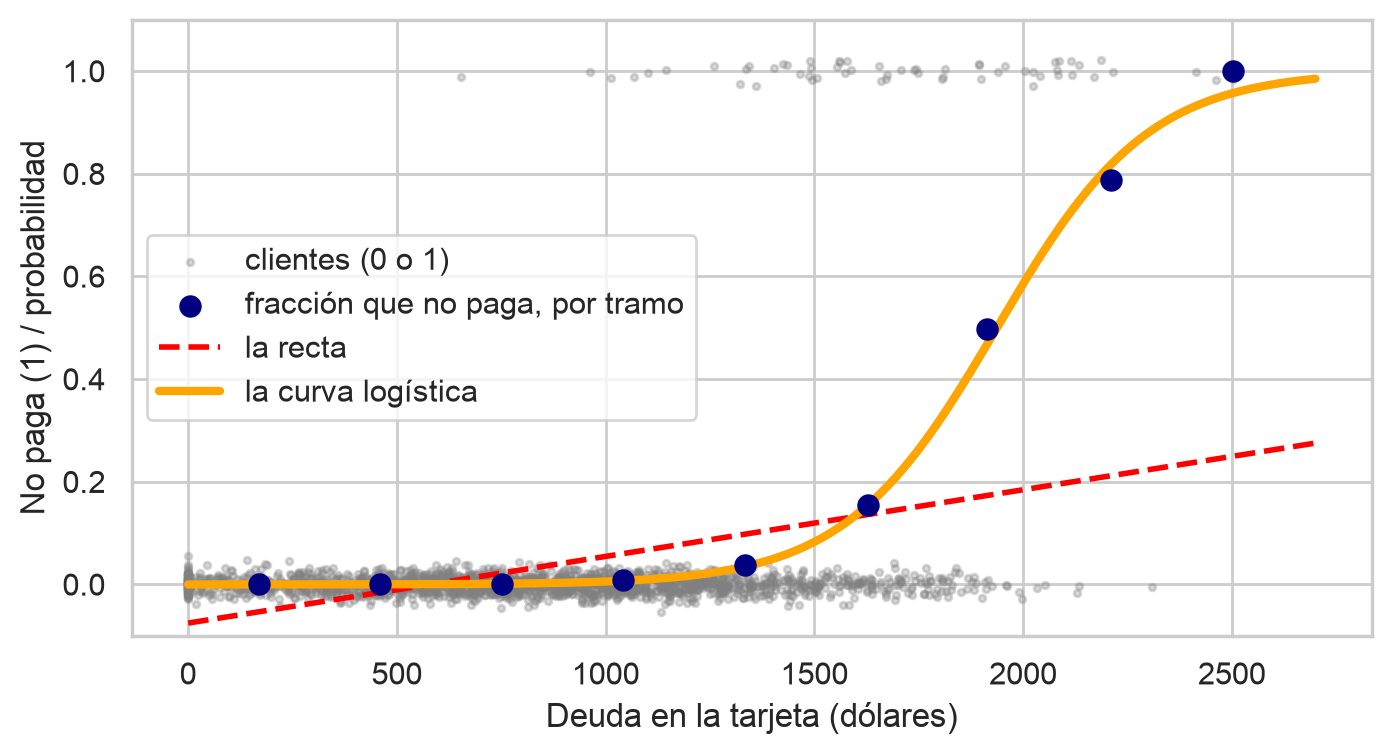

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(muestra["balance"], muestra["no_paga"] + np.random.default_rng(1).normal(0, 0.015, len(muestra)), s=6, alpha=0.3, color="gray", label="clientes (0 o 1)")
ax.scatter(ok["deuda"], ok["fraccion"], s=50, color="navy", zorder=5, label="fracción que no paga, por tramo")
ax.plot(grilla, a_r + b_r * grilla / 100, color="red", lw=2, ls="--", label="la recta")
ax.plot(grilla, sigmoide(a + b * grilla / 100), color="orange", lw=3, label="la curva logística")
ax.set(xlabel="Deuda en la tarjeta (dólares)", ylabel="No paga (1) / probabilidad", ylim=(-0.1, 1.1))
ax.legend()
plt.show()

La curva pasa por las fracciones de cada tramo: es la S que la recta no podía dibujar.

### El mismo summary

Las columnas son las de la clase 5: **coef**, **std err**, **z**, **P>|z|** y el intervalo. La única diferencia es $z$ en lugar de $t$: con 10.000 clientes la referencia es la normal en vez de la t de Student, y $P>|z|$ se lee igual que $P>|t|$.

In [20]:
logistica.summary().tables[1]

,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,-10.6513,0.361,-29.491,0.000,-11.359,-9.943
deuda_100,0.5499,0.022,24.952,0.000,0.507,0.593


El intervalo de $b$ también se puede pasar a odds con `np.exp`: el multiplicador por cada 100 dólares está entre 1,66 y 1,81.

In [21]:
intervalo = logistica.conf_int().loc["deuda_100"]
print(f"b entre {intervalo.iloc[0]:.3f} y {intervalo.iloc[1]:.3f}")
print(f"e^b entre {np.exp(intervalo.iloc[0]):.2f} y {np.exp(intervalo.iloc[1]):.2f}")

b entre 0.507 y 0.593
e^b entre 1.66 y 1.81


## 6. Varias variables

**Objetivo:** agregar variables, numéricas y dummies, y leer cada e^b.

Los estudiantes, solos, dejan de pagar más que el resto:

In [22]:
print(clientes.groupby("student")["no_paga"].mean().rename("fracción que no paga"))
print(clientes.groupby("student")["balance"].mean().rename("deuda media"))

solo_estudiante = smf.logit("no_paga ~ estudiante", data=clientes).fit(disp=0)
print(f"\nsolo estudiante: b = {solo_estudiante.params['estudiante']:.3f}, e^b = {np.exp(solo_estudiante.params['estudiante']):.2f}")

student
No    0.029
Yes   0.043
Name: fracción que no paga, dtype: float64
student
No    771.770
Yes   987.818
Name: deuda media, dtype: float64

solo estudiante: b = 0.405, e^b = 1.50


Pero los estudiantes también deben más. ¿Qué pasa con el coeficiente de estudiante cuando la deuda entra al modelo? Es la misma pregunta de la regresión múltiple de la clase 4, y `estudiante` es una dummy como lo era el modo de transporte:

In [23]:
multiple = smf.logit("no_paga ~ deuda_100 + ingreso_miles + estudiante", data=clientes).fit(disp=0)
multiple.summary().tables[1]

,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,-10.8690,0.492,-22.079,0.000,-11.834,-9.904
deuda_100,0.5737,0.023,24.737,0.000,0.528,0.619
ingreso_miles,0.0030,0.008,0.370,0.712,-0.013,0.019
estudiante,-0.6468,0.236,-2.738,0.006,-1.110,-0.184


In [24]:
np.exp(multiple.params).rename("e^b: multiplicador de los odds")

Intercept       0.000
deuda_100       1.775
ingreso_miles   1.003
estudiante      0.524
Name: e^b: multiplicador de los odds, dtype: float64

El coeficiente de estudiante cambió de signo: a igual deuda e ingreso, los odds de un estudiante son la **mitad** (e^b = 0,52). Solos parecían peores pagadores porque deben más, y lo que explica el no pago es la deuda. Es la confusión de variables de la clase 4, ahora en la logística. El ingreso no aporta nada con la deuda en el modelo (p = 0,71).

### Ejemplo 2: el Titanic

891 pasajeros, del repositorio de datos de ejemplo de seaborn. La respuesta es si sobrevivieron; las variables, el sexo, la clase del pasaje (1, 2 o 3) y la edad, que falta en 177 pasajeros: el modelo usa los 714 con edad conocida.

In [25]:
pasajeros = pd.read_csv(BASE + "titanic.csv")
pasajeros["sobrevivio"] = pasajeros["survived"]
pasajeros["sexo"] = pasajeros["sex"].map({"female": "mujer", "male": "hombre"})
pasajeros["clase"] = pasajeros["pclass"]
pasajeros["edad"] = pasajeros["age"]
print("pasajeros:", len(pasajeros), "| sobrevivió:", round(pasajeros["sobrevivio"].mean(), 3), "| sin edad:", pasajeros["edad"].isna().sum())
pasajeros.groupby(["clase", "sexo"])["sobrevivio"].mean().unstack()

pasajeros:

 891 | sobrevivió: 0.384 | sin edad: 177


sexo,hombre,mujer
clase,,
1,0.369,0.968
2,0.157,0.921
3,0.135,0.500


La clase es categórica aunque sea un número: `C(clase)` le dice a statsmodels que cree las dummies (segunda y tercera clase, con la primera como referencia). El sexo es texto, así que la dummy se crea sola, con `hombre` como referencia por orden alfabético.

In [26]:
con_edad = pasajeros.dropna(subset=["edad"])
titanic = smf.logit("sobrevivio ~ sexo + C(clase) + edad", data=con_edad).fit(disp=0)
titanic.summary().tables[1]

,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,1.2542,0.360,3.485,0.000,0.549,1.960
sexo[T.mujer],2.5228,0.207,12.164,0.000,2.116,2.929
C(clase)[T.2],-1.3098,0.278,-4.710,0.000,-1.855,-0.765
C(clase)[T.3],-2.5806,0.281,-9.169,0.000,-3.132,-2.029
edad,-0.0370,0.008,-4.831,0.000,-0.052,-0.022


In [27]:
np.exp(titanic.params).rename("e^b: multiplicador de los odds")

Intercept        3.505
sexo[T.mujer]   12.463
C(clase)[T.2]    0.270
C(clase)[T.3]    0.076
edad             0.964
Name: e^b: multiplicador de los odds, dtype: float64

Cada e^b compara con su referencia, a igualdad de las otras variables: los odds de sobrevivir de una mujer son 12 veces las de un hombre; las de la tercera clase, el 8% de las de la primera; y cada año de edad las multiplica por 0,96. Con varias variables, `predict` suma los aportes en la recta y la sigmoide entrega la probabilidad:

In [28]:
perfiles = pd.DataFrame({
    "sexo": ["mujer", "mujer", "hombre", "hombre"],
    "clase": [1, 3, 1, 3],
    "edad": [30, 30, 30, 30],
})
perfiles["P_sobrevive"] = titanic.predict(perfiles)
perfiles

,sexo,clase,edad,P_sobrevive
0,mujer,1,30,0.935
1,mujer,3,30,0.522
2,hombre,1,30,0.536
3,hombre,3,30,0.080


## 7. Clasificar: de la probabilidad a la decisión

**Objetivo:** convertir la probabilidad en un sí o no, y medir los dos errores.

El modelo entrega probabilidades. Para decidir hace falta un **umbral**: el más simple es 0,5. La tabla de lo real contra lo predicho es la **matriz de confusión**, y tiene cuatro celdas con nombre:

| | predicho sí | predicho no |
|---|---|---|
| **real sí** | verdadero positivo (VP) | **falso negativo (FN)** |
| **real no** | **falso positivo (FP)** | verdadero negativo (VN) |

Un **falso negativo** es un sí que el modelo declaró no: un cliente que no pagará y recibió la tarjeta. Un **falso positivo** es un no declarado sí: un cliente que sí pagaba y a quien se le negó. No cuestan lo mismo, y cuál cuesta más lo dice el problema, no el modelo.

In [29]:
clientes["prob"] = logistica.predict(clientes)
clientes["prediccion"] = (clientes["prob"] >= 0.5).astype(int)

# La matriz de confusión: crosstab de lo real contra lo predicho
pd.crosstab(clientes["no_paga"], clientes["prediccion"], rownames=["real"], colnames=["predicho"])

predicho,0,1
real,,
0,9625,42
1,233,100


De los 333 clientes que no pagan, el modelo detecta 100 y se le escapan 233 (falsos negativos); a 42 clientes que sí pagan los declara morosos (falsos positivos). ¿Y la **exactitud**, la fracción de aciertos?

In [30]:
exactitud = (clientes["prediccion"] == clientes["no_paga"]).mean()
base = 1 - clientes["no_paga"].mean()   # decir siempre "paga", la clase mayoritaria
print(f"exactitud del modelo: {exactitud:.4f}")
print(f"decir siempre \"paga\": {base:.4f}")

exactitud del modelo: 0.9725
decir siempre "paga": 0.9667


97,3% contra 96,7%: casi lo mismo que no tener modelo. Cuando el sí es raro (3,3%), la exactitud mide sobre todo lo fácil, los noes. Hay que contar los dos errores por separado: 233 falsos negativos (7 de cada 10 clientes que no pagan se le escapan al modelo) y 42 falsos positivos. Si al banco le cuesta más el falso negativo, convendría bajar el umbral y aceptar más falsos positivos; cómo elegir el umbral según el costo de cada error, y las medidas que resumen los dos errores (sensibilidad y especificidad), quedan para la próxima clase.

### El Titanic como clasificador

Con un sí frecuente (41% sobrevivió), la exactitud sí informa:

In [31]:
con_edad = con_edad.copy()
con_edad["prob"] = titanic.predict(con_edad)
con_edad["prediccion"] = (con_edad["prob"] >= 0.5).astype(int)
print(pd.crosstab(con_edad["sobrevivio"], con_edad["prediccion"], rownames=["real"], colnames=["predicho"]))
print(f"\nexactitud del modelo: {(con_edad['prediccion'] == con_edad['sobrevivio']).mean():.3f}")
print(f"decir siempre \"murió\": {1 - con_edad['sobrevivio'].mean():.3f}")

predicho    0    1
real              
0         356   68
1          83  207

exactitud del modelo: 0.789
decir siempre "murió": 0.594


79% de aciertos contra el 59% de decir que todos murieron: el modelo aporta 20 puntos. Los errores: 83 falsos negativos, pasajeros que sobrevivieron y el modelo daba por muertos (hombres jóvenes de tercera clase), y 68 falsos positivos.

## 8. Evaluar fuera de la muestra

**Objetivo:** medir el modelo en datos que no usó para ajustarse.

Todas las exactitudes anteriores se midieron en los mismos datos con que se ajustó el modelo, y eso es hacer trampa: el modelo ya los vio. La medida honesta se toma en una parte de **prueba** separada al azar antes de ajustar; la otra parte, de **entrenamiento**, es la única que ve el modelo.

In [32]:
rng = np.random.default_rng(7)
en_entrenamiento = rng.random(len(con_edad)) < 0.7   # True para el 70% de las filas, al azar
entrenamiento = con_edad[en_entrenamiento]
prueba = con_edad[~en_entrenamiento]
print(f"entrenamiento: {len(entrenamiento)} pasajeros | prueba: {len(prueba)}")

modelo_e = smf.logit("sobrevivio ~ sexo + C(clase) + edad", data=entrenamiento).fit(disp=0)
for nombre, datos in [("entrenamiento", entrenamiento), ("prueba", prueba)]:
    aciertos = ((modelo_e.predict(datos) >= 0.5).astype(int) == datos["sobrevivio"]).mean()
    print(f"exactitud en {nombre}: {aciertos:.3f}")

entrenamiento: 496 pasajeros | prueba: 218
exactitud en entrenamiento: 0.778
exactitud en prueba: 0.830


Con un modelo simple como este las dos cifras se parecen, y que la de prueba salga un poco más alta o más baja es cosa del azar del reparto: buena señal, el modelo no aprendió el azar de su muestra. Con modelos más flexibles la exactitud de entrenamiento sube y la de prueba no, y la de prueba es la única que vale. Este es el punto de partida de la evaluación de modelos que sigue en el diplomado.

---

**Próxima clase (martes 15-sep):** sensibilidad y especificidad, cómo elegir el umbral según el costo de cada error y la curva ROC; después, regresión regularizada, Ridge y Lasso. Recuerde: el primer análisis exploratorio se entrega el martes 15 de septiembre.